In [2]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
print("Tensorflow version: ", tf.__version__)
print("KEras version: ", tf.keras.__version__)

Tensorflow version:  2.21.0
KEras version:  3.13.2


In [4]:
url = "https://raw.githubusercontent.com/GauravSisodia/Keras-Course/main/heart_disease.csv"

heart_disease_df = pd.read_csv(url)

heart_disease_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
heart_disease_df.shape

(303, 14)

In [6]:
heart_disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
X = heart_disease_df.drop('target', axis = 1) #axis = 1 means a column will be dropped
y = heart_disease_df['target']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [10]:
#building model and defining the sequential model
model = Sequential()
input_dims = X_train.shape[1]
model.add(tf.keras.Input(shape = (input_dims,), name = "input_layer"))
model.add(Dense(32, activation = 'relu', name = "hidden_layer1"))
model.add(Dense(16, activation = 'relu', name = "hidden_layer2"))
model.add(Dense(8, activation = 'relu', name = "hidden_layer3"))
model.add(Dense(1, activation = "sigmoid", name = "output_layer"))

#contains 4 layers
#last node uses 'sigmoid' activation function that will squeezes all valyes b/w 0 and 1.
#other layers uses ReLU as activation function. it is a half rectified function that is, for all inputs
#less than 0. The value is 0 while for anything positive the value is retained.
#if output unit is high, then person has a heart disease and if it is less, then the person does not have a heart disease.

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer1 (Dense)           │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer2 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer3 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

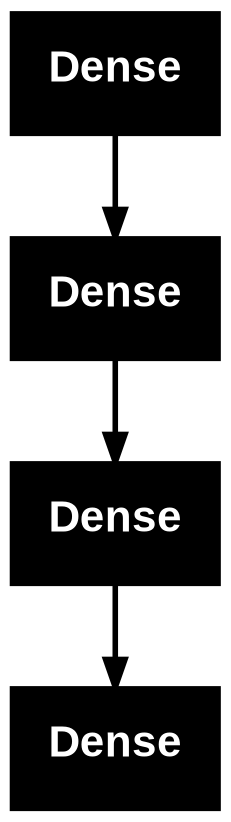

In [12]:
from tensorflow.keras.utils import plot_model
plot_model(model)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer1 (Dense)           │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer2 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer3 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4560 - loss: 1.5139 - val_accuracy: 0.4286 - val_loss: 1.1821
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4560 - loss: 0.9971 - val_accuracy: 0.4286 - val_loss: 0.8746
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4456 - loss: 0.8025 - val_accuracy: 0.3673 - val_loss: 0.7667
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3627 - loss: 0.7379 - val_accuracy: 0.3673 - val_loss: 0.7357
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4819 - loss: 0.7275 - val_accuracy: 0.5306 - val_loss: 0.7298
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5233 - loss: 0.7245 - val_accuracy: 0.5510 - val_loss: 0.7278
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5389 - loss: 0.7304 - val_accuracy: 0.5510 - val_loss: 0.7270
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5440 - loss: 0.7312 - val_accuracy: 0.5510 - val_loss: 0.7241


In [16]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6393 - loss: 0.6470


[0.6470373272895813, 0.6393442749977112]

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer1 (Dense)           │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer2 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer3 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365 (13.15 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,244 (8.77 KB)

In [18]:
#importing the optimizer
from tensorflow.keras.optimizers import RMSprop

#defining the optimizer. RMSprop is an object of library RMSprop. learning rate is 0.01(step value)
optimizer = RMSprop(0.001)

#hyperparameter is a setting that YOU choose before/during training. The neural network does not learn these values automatically from the training data.
#for eg-: learning rate, optimizer, metrics, batch size, activation func

#optimizer updates weights and biases to minimize the losses.
#accuracy evaluates the performance of NN.
#binary-cross-entropy is a loss func that gives loss in form of probability.
#optimizer-:
#Adam > Gradient descent > stochastic gradient descent > Ada Delta
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [19]:
batch_size = 128
num_epochs = 20
multiclass_classifier = model.fit(
    X_train,
    y_train,
    validation_split=0.2, #20%
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.6269 - loss: 0.6675 - val_accuracy: 0.6531 - val_loss: 0.6466
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5959 - loss: 0.6709 - val_accuracy: 0.6735 - val_loss: 0.6457
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6114 - loss: 0.6610 - val_accuracy: 0.6735 - val_loss: 0.6424
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6218 - loss: 0.6578 - val_accuracy: 0.6735 - val_loss: 0.6388
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6321 - loss: 0.6561 - val_accuracy: 0.6735 - val_loss: 0.6355
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6010 - loss: 0.6545 - val_accuracy: 0.6735 - val_loss: 0.6341
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6373 - loss: 0.6526 - val_accuracy: 0.6735 - val_loss: 0.6315
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6321 - loss: 0.6513 - val_accuracy: 0.6327 - val_loss: 0.6285

In [20]:
score = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.587219774723053
Test accuracy: 0.7377049326896667


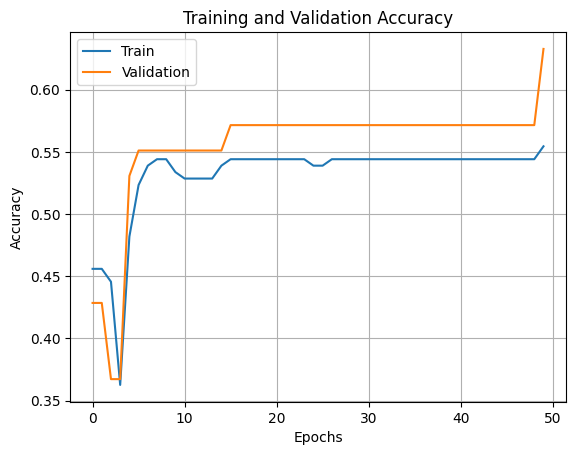

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()

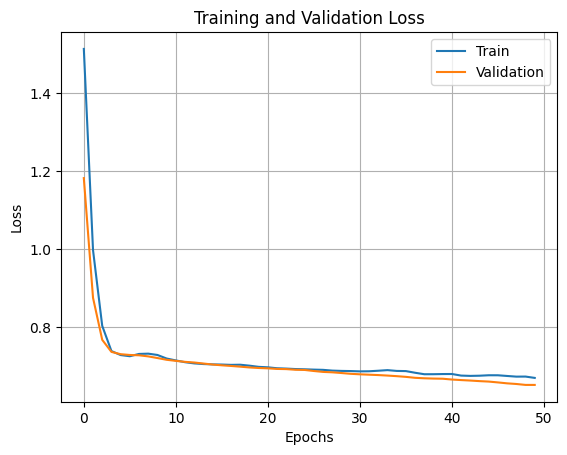

In [22]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid()
plt.show()

In [23]:
y_pred = model.predict(X_test)

print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.37201715]
 [0.4982142 ]
 [0.69568473]
 [0.40015957]
 [0.45370516]
 [0.65771896]
 [0.57455486]
 [0.3679291 ]
 [0.40279374]
 [0.5476871 ]]


In [24]:
y_pred_binary = (y_pred > 0.5).astype(int)

print(y_pred_binary[:10])

[[0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]]


In [25]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [26]:
y_pred_prob = model.predict(X_test)

print(y_pred_prob[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.37201715]
 [0.4982142 ]
 [0.69568473]
 [0.40015957]
 [0.45370516]
 [0.65771896]
 [0.57455486]
 [0.3679291 ]
 [0.40279374]
 [0.5476871 ]]


In [27]:
y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred[:10])

[[0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted probabilities:
[0.37201715 0.4982142  0.69568473 0.40015957 0.45370516 0.65771896
 0.57455486 0.3679291  0.40279374 0.5476871 ]

Predicted classes:
[0 0 1 0 0 1 1 0 0 1]


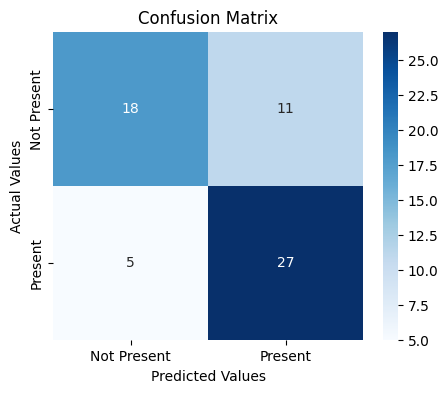

----------------------------------------------------------------------------------------------------
Classification Report:

              precision    recall  f1-score   support

 Not Present       0.78      0.62      0.69        29
     Present       0.71      0.84      0.77        32

    accuracy                           0.74        61
   macro avg       0.75      0.73      0.73        61
weighted avg       0.74      0.74      0.73        61

Accuracy Score: 73.77049180327869
AUC Score: 0.8329741379310346


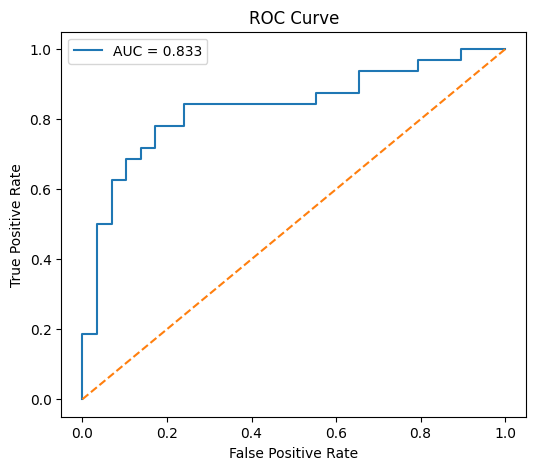

In [28]:
#creating confusion matrix
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 1. Get predicted probabilities
y_pred_prob = model.predict(X_test).ravel()
print("Predicted probabilities:")
print(y_pred_prob[:10])


# 2. Convert probabilities into 0/1 predictions
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nPredicted classes:")
print(y_pred[:10])


#confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ["Not Present", "Present"]

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")

plt.show()


#classification report
print("-" * 100)
print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))


#accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy * 100)


#roc curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)


#auc score
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)


#plot roc curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()